>>> [ЕТАП 1 & 2] Завантаження набору даних...
Дані успішно завантажено. Розмірність: 100000 рядків, 28 колонок.
      Conflict_Name                  Conflict_Type       Region  Start_Year  \
0      WWII (Japan)                      World War    East Asia        1939   
1  Israel-Hamas War                 Asymmetric War  Middle East        2023   
2  Syrian Civil War                      Civil War  Middle East        2011   
3    WWII (Germany)                      World War       Europe        1939   
4   Afghanistan War  Interstate/Counter-insurgency   South Asia        2001   

   End_Year    Status   Primary_Country  Pre_War_Unemployment_%  \
0      1945  Resolved             Japan                    7.49   
1      2026   Ongoing  Palestine (Gaza)                    8.18   
2      2026   Ongoing             Syria                   12.70   
3      1945  Resolved           Germany                   14.06   
4      2021  Resolved       Afghanistan                    5.38   

   During_

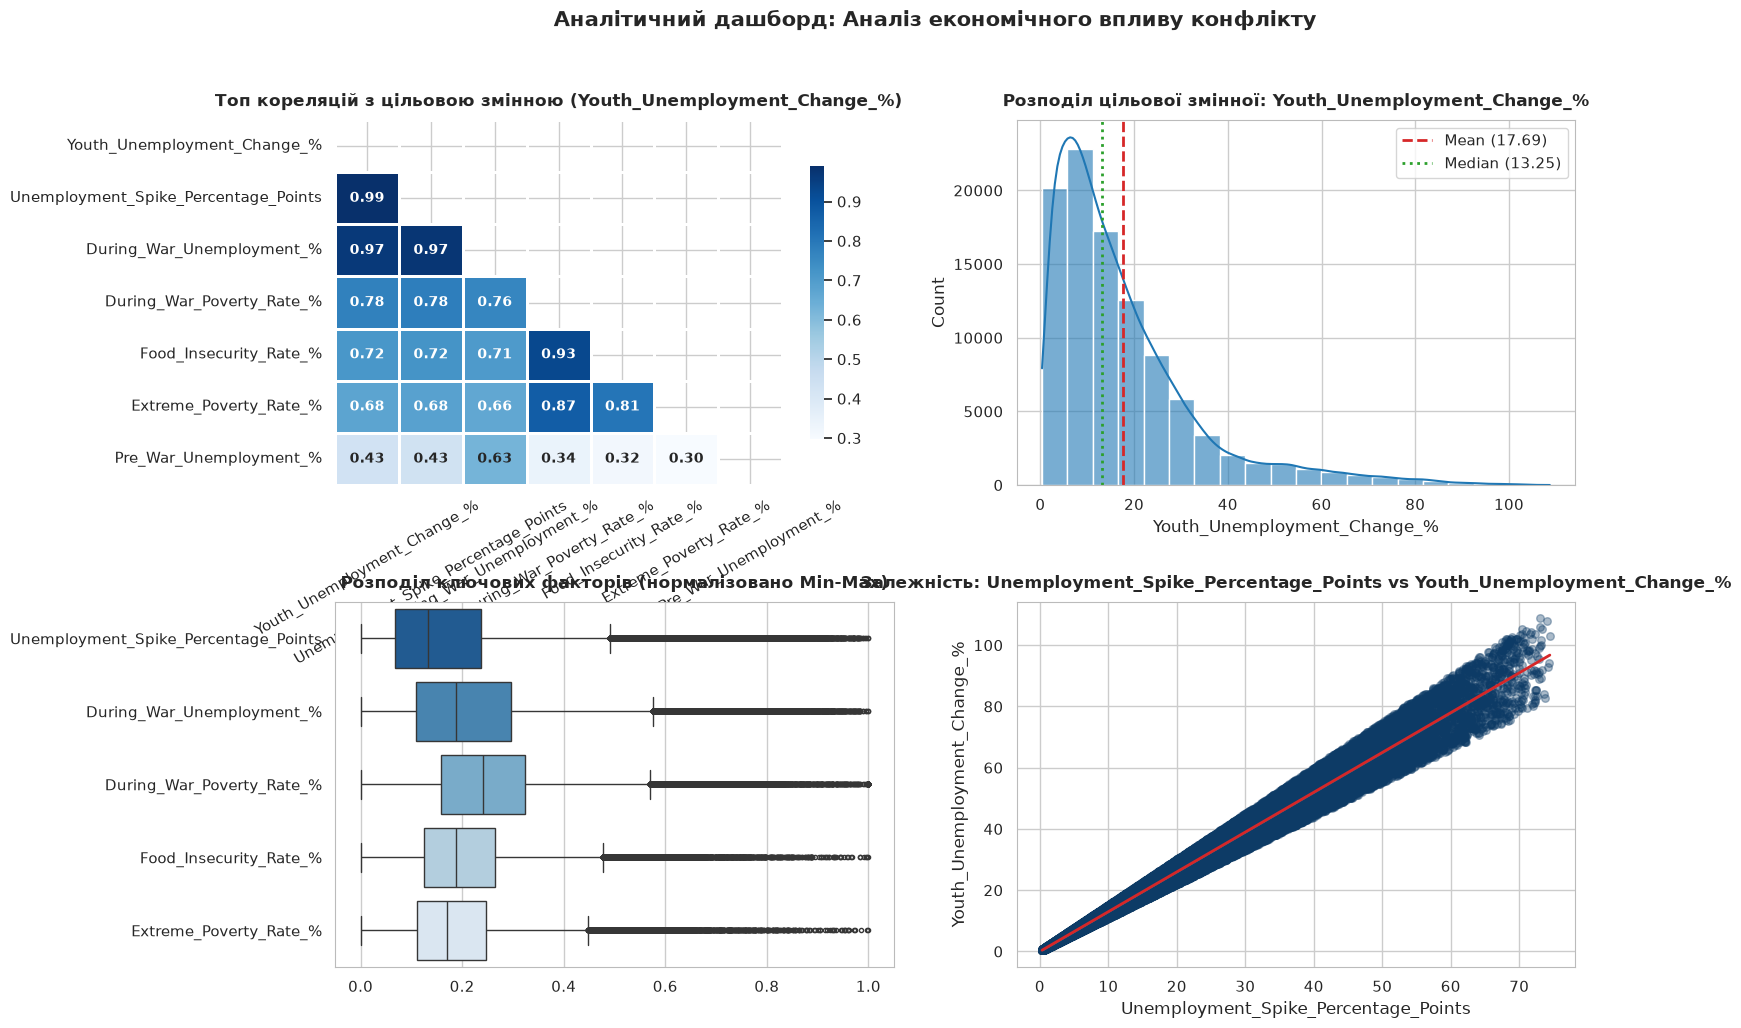


>>> [АНІМАЦІЯ] Генерація динамічних графіків...


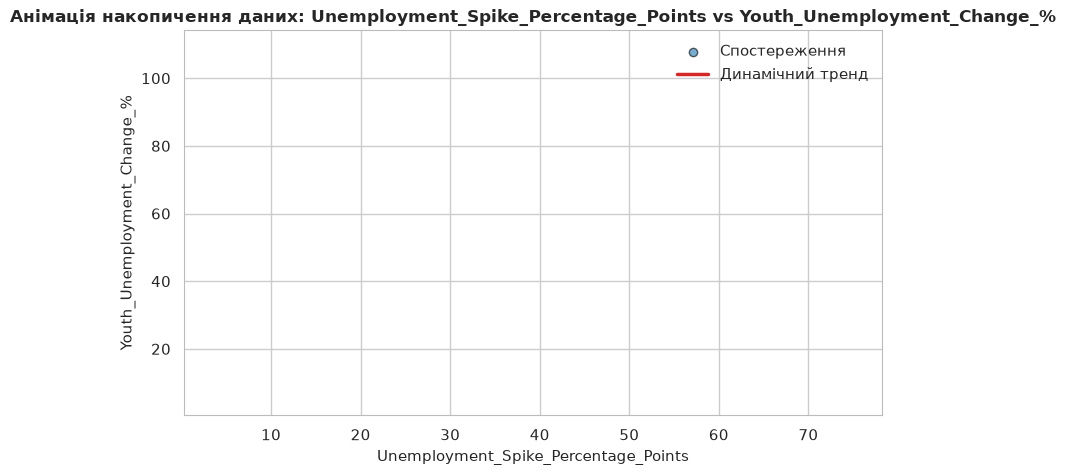

Формування інтерактивної часової шкали Plotly...
Інтерактивну анімацію збережено у файл: interactive_evolution.html
Для перегляду інтерактивного графіка відкрийте 'interactive_evolution.html' у браузері.

>>> [ЕТАП 7] Навчання моделей регресії...
--- Linear Regression ---
R² Score: 0.9822
MAE:      1.3639
RMSE:     2.0979

--- Random Forest Regressor ---
R² Score: 0.9812
MAE:      1.3842
RMSE:     2.1577



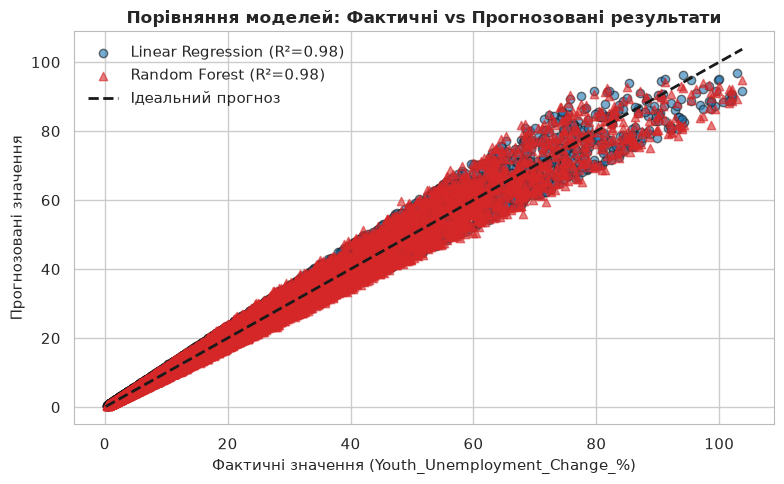

>>> [ЕТАП 8] Робота виконана. Збережено графічні звіти 'eda_dashboard.png' та 'model_evaluation.png'.


In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 0. СТИЛІЗАЦІЯ ТА КОНФІГУРАЦІЯ
# ==============================================================================
DATASET_PATH = r"C:\Users\day2026\Documents\IAZprak\war_economic_impact_dataset.csv"

# Налаштування стилів (запобігає попередженню findfont)
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
plt.rcParams['axes.edgecolor'] = '#bbbbbb'
plt.rcParams['axes.linewidth'] = 0.8

# ==============================================================================
# 1. ЗАВАНТАЖЕННЯ ДАНИХ (Data Ingestion)
# ==============================================================================
print(">>> [ЕТАП 1 & 2] Завантаження набору даних...")

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Файл не знайдено за вказаним шляхом: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
print(f"Дані успішно завантажено. Розмірність: {df.shape[0]} рядків, {df.shape[1]} колонок.")
print(df.head())
print("\nЗагальна інформація про типи колонок:")
df.info()

# ==============================================================================
# 2. ОЧИЩЕННЯ ДАНИХ (Data Hygiene)
# ==============================================================================
print("\n>>> [ЕТАП 3] Очищення пропусків та дублікатів...")

initial_rows = len(df)
df = df.drop_duplicates()
print(f"Видалено дублікатів: {initial_rows - len(df)}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Заповнення пропусків: числовим — медіана, текстовим — найчастіше значення (мода)
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Кількість невирішених пропусків після імпутації: {df.isnull().sum().sum()}")

# ==============================================================================
# 3. ТРАНСФОРМАЦІЯ ТА ВИБІР ОЗНАК (Feature Engineering)
# ==============================================================================
print("\n>>> [ЕТАП 4 & 5] Трансформація змінних та декомпозиція...")

# Визначення цільової змінної: шукаємо колонку GDP/Growth/Impact або останню числову
target_candidates = [c for c in num_cols if 'gdp' in c.lower() or 'growth' in c.lower() or 'change' in c.lower()]
TARGET_COL = target_candidates[0] if target_candidates else num_cols[-1]
print(f"Обрано цільову змінну (Target): '{TARGET_COL}'")

# Відокремлюємо часові колонки (роки, ID), які не несуть фізичного економічного зв'язку
cols_to_exclude = [c for c in num_cols if 'year' in c.lower() or 'id' in c.lower()]
clean_num_cols = [c for c in num_cols if c not in cols_to_exclude]

# Відбір топ-корелюючих числових ознак для чіткого дашборду
corr_series = df[clean_num_cols].corr()[TARGET_COL].abs().sort_values(ascending=False)
top_features = corr_series.head(7).index.tolist()
best_feature = [f for f in top_features if f != TARGET_COL][0]

# One-Hot Encoding категоріальних змінних
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Декомпозиція на Train/Test (80% / 20%)
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Розмір Train вибірки: {X_train.shape}, Test вибірки: {X_test.shape}")

# Нормалізація ознак (Min-Max Scaling)
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# 4. ОПИСОВА СТАТИСТИКА ТА ВІЗУАЛІЗАЦІЯ (Static Dashboard)
# ==============================================================================
print("\n>>> [ЕТАП 6] Побудова аналітичного дашборду (без накладання тексту)...")

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.22)

# 1. Чітка матриця кореляцій (лише топ-ознаки)
ax1 = fig.add_subplot(gs[0, 0])
sub_corr = df[top_features].corr()
mask = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(
    sub_corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='Blues', 
    cbar_kws={'shrink': 0.75}, 
    annot_kws={"size": 10, "weight": "bold"},
    linewidths=1.0, 
    ax=ax1
)
ax1.set_title(f"Топ кореляцій з цільовою змінною ({TARGET_COL})", fontsize=12, fontweight='bold', pad=10)
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# 2. Розподіл цільової змінної
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df[TARGET_COL], kde=True, color='#1f77b4', ax=ax2, bins=20, alpha=0.6)
ax2.axvline(df[TARGET_COL].mean(), color='#d62728', linestyle='--', linewidth=2, label=f"Mean ({df[TARGET_COL].mean():.2f})")
ax2.axvline(df[TARGET_COL].median(), color='#2ca02c', linestyle=':', linewidth=2, label=f"Median ({df[TARGET_COL].median():.2f})")
ax2.set_title(f"Розподіл цільової змінної: {TARGET_COL}", fontsize=12, fontweight='bold', pad=10)
ax2.legend(frameon=True)

# 3. Боксплот ключових числових змінних (нормалізований для наочності)
ax3 = fig.add_subplot(gs[1, 0])
box_scaler = MinMaxScaler()
box_features = [f for f in top_features if f != TARGET_COL][:5]
scaled_box_df = pd.DataFrame(box_scaler.fit_transform(df[box_features]), columns=box_features)
sns.boxplot(data=scaled_box_df, orient='h', palette='Blues_r', ax=ax3, fliersize=3)
ax3.set_title("Розподіл ключових факторів (нормалізовано Min-Max)", fontsize=12, fontweight='bold', pad=10)

# 4. Регресійна діаграма розсіювання (найсильніший предиктор)
ax4 = fig.add_subplot(gs[1, 1])
sns.regplot(
    data=df, 
    x=best_feature, 
    y=TARGET_COL, 
    ax=ax4, 
    scatter_kws={'alpha': 0.35, 'color': '#0d3b66', 's': 30},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
ax4.set_title(f"Залежність: {best_feature} vs {TARGET_COL}", fontsize=12, fontweight='bold', pad=10)

plt.suptitle("Аналітичний дашборд: Аналіз економічного впливу конфлікту", fontsize=15, fontweight='bold', y=0.98)
plt.savefig("eda_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 5. АНІМАЦІЙНИЙ БЛОК (Dynamic Visuals)
# ==============================================================================
print("\n>>> [АНІМАЦІЯ] Генерація динамічних графіків...")

# Анімація 1: Matplotlib FuncAnimation (динамічна лінія тренду)
fig_anim, ax_anim = plt.subplots(figsize=(9, 5))
x_vals = df[best_feature].values
y_vals = df[TARGET_COL].values
sort_idx = np.argsort(x_vals)
x_vals = x_vals[sort_idx]
y_vals = y_vals[sort_idx]

scat = ax_anim.scatter([], [], color='#1f77b4', alpha=0.6, edgecolors='black', label='Спостереження')
line, = ax_anim.plot([], [], color='#d62728', linewidth=2.5, label='Динамічний тренд')

ax_anim.set_xlim(x_vals.min() * 0.95, x_vals.max() * 1.05)
ax_anim.set_ylim(y_vals.min() * 0.95, y_vals.max() * 1.05)
ax_anim.set_xlabel(best_feature, fontsize=11)
ax_anim.set_ylabel(TARGET_COL, fontsize=11)
ax_anim.set_title(f"Анімація накопичення даних: {best_feature} vs {TARGET_COL}", fontsize=12, fontweight='bold')
ax_anim.legend(loc='upper right')

def anim_init():
    scat.set_offsets(np.empty((0, 2)))
    line.set_data([], [])
    return scat, line

def anim_update(frame):
    cur_x = x_vals[:frame]
    cur_y = y_vals[:frame]
    scat.set_offsets(np.c_[cur_x, cur_y])
    if frame > 2:
        poly = np.polyfit(cur_x, cur_y, 1)
        line.set_data(cur_x, np.poly1d(poly)(cur_x))
    return scat, line

anim = animation.FuncAnimation(
    fig_anim, anim_update, init_func=anim_init, 
    frames=min(len(x_vals) + 1, 150), interval=25, blit=True, repeat=False
)
plt.show()

# Анімація 2: Plotly Express (Збереження у файл без ризику помилки nbformat)
year_col = [c for c in df.columns if 'year' in c.lower()]
country_col = [c for c in df.columns if 'country' in c.lower() or 'region' in c.lower()]

if year_col and country_col:
    print("Формування інтерактивної часової шкали Plotly...")
    fig_plotly = px.scatter(
        df,
        x=best_feature,
        y=TARGET_COL,
        animation_frame=year_col[0],
        animation_group=country_col[0],
        color=country_col[0],
        hover_name=country_col[0],
        template="plotly_white",
        title=f"Еволюція у часі: {best_feature} vs {TARGET_COL}"
    )
    fig_plotly.update_layout(transition={'duration': 800})
    fig_plotly.write_html("interactive_evolution.html")
    print("Інтерактивну анімацію збережено у файл: interactive_evolution.html")
    
    # Спроба відобразити в середовищі без переривання програми у разі відсутності модулів
    try:
        import nbformat
        fig_plotly.show()
    except Exception:
        print("Для перегляду інтерактивного графіка відкрийте 'interactive_evolution.html' у браузері.")

# ==============================================================================
# 6. ПОБУДОВА ТА ВАЛІДАЦІЯ МОДЕЛІ (Machine Learning)
# ==============================================================================
print("\n>>> [ЕТАП 7] Навчання моделей регресії...")

# Модель 1: Лінійна регресія
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Модель 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

def print_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}\n")
    return r2, mae, rmse

lr_res = print_metrics(y_test, lr_preds, "Linear Regression")
rf_res = print_metrics(y_test, rf_preds, "Random Forest Regressor")

# Графік порівняння точності моделей: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, color='#1f77b4', alpha=0.6, edgecolors='k', label=f'Linear Regression (R²={lr_res[0]:.2f})')
plt.scatter(y_test, rf_preds, color='#d62728', alpha=0.6, marker='^', label=f'Random Forest (R²={rf_res[0]:.2f})')
min_val = min(y_test.min(), min(lr_preds.min(), rf_preds.min()))
max_val = max(y_test.max(), max(lr_preds.max(), rf_preds.max()))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ідеальний прогноз')

plt.xlabel(f"Фактичні значення ({TARGET_COL})", fontsize=11)
plt.ylabel("Прогнозовані значення", fontsize=11)
plt.title("Порівняння моделей: Фактичні vs Прогнозовані результати", fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=300)
plt.show()

print(">>> [ЕТАП 8] Робота виконана. Збережено графічні звіти 'eda_dashboard.png' та 'model_evaluation.png'.")